# 02: STRING Interaction Fetching

This notebook handles:
- Loading high pLLPS proteins from previous step
- Fetching protein-protein interactions from STRING database
- Matching interactions to pLLPS dataset
- Saving interaction data for downstream analysis

**Inputs:**
- `results/high_pllps_proteins.csv` - From notebook 01
- `results/full_dataset.csv` - From notebook 01

**Outputs:**
- `results/string_interactions_raw.csv` - Raw STRING interactions
- `results/string_interactions_matched.csv` - Interactions matched to pLLPS data
- `results/interaction_summary.json` - Summary statistics

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import llps_functions as lf
from pathlib import Path

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Previous Results

In [2]:
# Check available results
lf.list_saved_results()

📁 Found 13 result files in results:
   - classification_summary.json (0.4 KB)
   - communities_analysis.csv (2.7 KB)
   - full_dataset.csv (18.7 MB)
   - functional_group_interactions.csv (0.4 KB)
   - functional_group_pllps_analysis.csv (0.3 KB)
   - high_pllps_clusters.csv (2.6 KB)
   - high_pllps_hubs.csv (16.0 KB)
   - high_pllps_proteins.csv (6.1 MB)
   - high_pllps_proteins_connectivity.csv (23.6 KB)
   - hub_analysis_full.csv (311.4 KB)
   - llps_driven_clusters.csv (0.2 KB)
   - membrane_proteins.csv (6.9 MB)
   - membrane_proteins_full.csv (9.9 MB)


['classification_summary.json',
 'communities_analysis.csv',
 'full_dataset.csv',
 'functional_group_interactions.csv',
 'functional_group_pllps_analysis.csv',
 'high_pllps_clusters.csv',
 'high_pllps_hubs.csv',
 'high_pllps_proteins.csv',
 'high_pllps_proteins_connectivity.csv',
 'hub_analysis_full.csv',
 'llps_driven_clusters.csv',
 'membrane_proteins.csv',
 'membrane_proteins_full.csv']

In [3]:
# Load datasets
df_full = lf.load_analysis_result('full_dataset', format='csv')
df_high = lf.load_analysis_result('high_pllps_proteins', format='csv')

print(f"\n📊 Loaded data:")
print(f"   Full dataset: {len(df_full)} proteins")
print(f"   High pLLPS: {len(df_high)} proteins")

✅ Loaded CSV from: results/full_dataset.csv (20366 rows)
✅ Loaded CSV from: results/high_pllps_proteins.csv (6657 rows)

📊 Loaded data:
   Full dataset: 20366 proteins
   High pLLPS: 6657 proteins


## 2. Fetch STRING Interactions

⚠️ **Note:** This step makes API calls to STRING database. It may take several minutes depending on the number of proteins. Results will be cached to avoid re-fetching.

In [4]:
# Configuration
SCORE_THRESHOLD = 700  # STRING confidence score (400=low, 700=high, 900=highest)
#MAX_PROTEINS = 500  # Limit number of proteins to avoid excessive API calls

# Get protein IDs
protein_ids = df_high['Entry'].tolist()
print(f"\n🔍 Fetching interactions for {len(protein_ids)} high pLLPS proteins...")
print(f"   Score threshold: {SCORE_THRESHOLD}")


🔍 Fetching interactions for 6657 high pLLPS proteins...
   Score threshold: 700


In [5]:
# Check if we already have cached interactions
cache_file = Path('results/string_interactions_raw.csv')

if cache_file.exists():
    print("\n✅ Found cached interactions, loading from file...")
    interactions_df = lf.load_analysis_result('string_interactions_raw', format='csv')
    errors = []
else:
    print("\n⏳ Fetching interactions from STRING API...")
    print("   This may take several minutes. Progress will be shown below.")
    
    # Fetch interactions with progress callback
    interactions_df, errors = lf.fetch_string_interactions(
        protein_ids,
        score_threshold=SCORE_THRESHOLD,
        progress_callback=lambda msg: print(f"   {msg}")
    )
    
    if len(interactions_df) > 0:
        # Save raw interactions
        lf.save_analysis_result(interactions_df, 'string_interactions_raw', format='csv')
    else:
        print("\n⚠️  No interactions found!")


⏳ Fetching interactions from STRING API...
   This may take several minutes. Progress will be shown below.
   Fetching batch 1/67...
   Fetching batch 2/67...
   Fetching batch 3/67...
   Fetching batch 4/67...
   Fetching batch 5/67...
   Fetching batch 6/67...
   Fetching batch 7/67...
   Fetching batch 8/67...
   Fetching batch 9/67...
   Fetching batch 10/67...
   Fetching batch 11/67...
   Fetching batch 12/67...
   Fetching batch 13/67...
   Fetching batch 14/67...
   Fetching batch 15/67...
   Fetching batch 16/67...
   Fetching batch 17/67...
   Fetching batch 18/67...
   Fetching batch 19/67...
   Fetching batch 20/67...
   Fetching batch 21/67...
   Fetching batch 22/67...
   Fetching batch 23/67...
   Fetching batch 24/67...
   Fetching batch 25/67...
   Fetching batch 26/67...
   Fetching batch 27/67...
   Fetching batch 28/67...
   Fetching batch 29/67...
   Fetching batch 30/67...
   Fetching batch 31/67...
   Fetching batch 32/67...
   Fetching batch 33/67...
   Fetchin

In [13]:
# Show fetch results
print(f"\n📊 STRING Interaction Results:")
print(f"   Total interactions: {len(interactions_df)}")
if 'preferredName_A' in interactions_df.columns and 'preferredName_B' in interactions_df.columns:
    print(f"   Unique proteins with interactions: {len(set(interactions_df['preferredName_A'].tolist() + interactions_df['preferredName_B'].tolist()))}")

if errors:
    print(f"   ⚠️  Errors encountered: {len(errors)}")
    print(f"   First few errors: {errors[:3]}")

# Display sample interactions
print("\n📋 Sample interactions:")
interactions_df.head(10)


📊 STRING Interaction Results:
   Total interactions: 215
   Unique proteins with interactions: 339

📋 Sample interactions:


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,9606.ENSP00000262189,9606.ENSP00000436786,KMT2C,KMT2A,9606,0.831,0,0,0,0,0.321,0.00,0.761
1,9606.ENSP00000262189,9606.ENSP00000474253,KMT2C,SETD1B,9606,0.929,0,0,0,0,0.319,0.00,0.901
2,9606.ENSP00000262189,9606.ENSP00000301067,KMT2C,KMT2D,9606,0.997,0,0,0,0,0.240,0.90,0.963
3,9606.ENSP00000262518,9606.ENSP00000374212,SRCAP,EP400,9606,0.778,0,0,0,0,0.000,0.54,0.539
4,9606.ENSP00000268712,9606.ENSP00000364912,NCOR1,SPEN,9606,0.801,0,0,0,0,0.292,0.00,0.730
5,9606.ENSP00000268712,9606.ENSP00000384018,NCOR1,NCOR2,9606,0.997,0,0,0,0,0.457,0.80,0.982
6,9606.ENSP00000280772,9606.ENSP00000467141,ANK3,TTN,9606,0.784,0,0,0,0,0.000,0.00,0.784
7,9606.ENSP00000296452,9606.ENSP00000334319,BSN,PCLO,9606,0.800,0,0,0,0,0.000,0.80,0.000
8,9606.ENSP00000297954,9606.ENSP00000341292,WNK2,WNK1,9606,0.959,0,0,0,0,0.959,0.00,0.000
9,9606.ENSP00000301067,9606.ENSP00000474253,KMT2D,SETD1B,9606,0.712,0,0,0,0,0.321,0.00,0.593


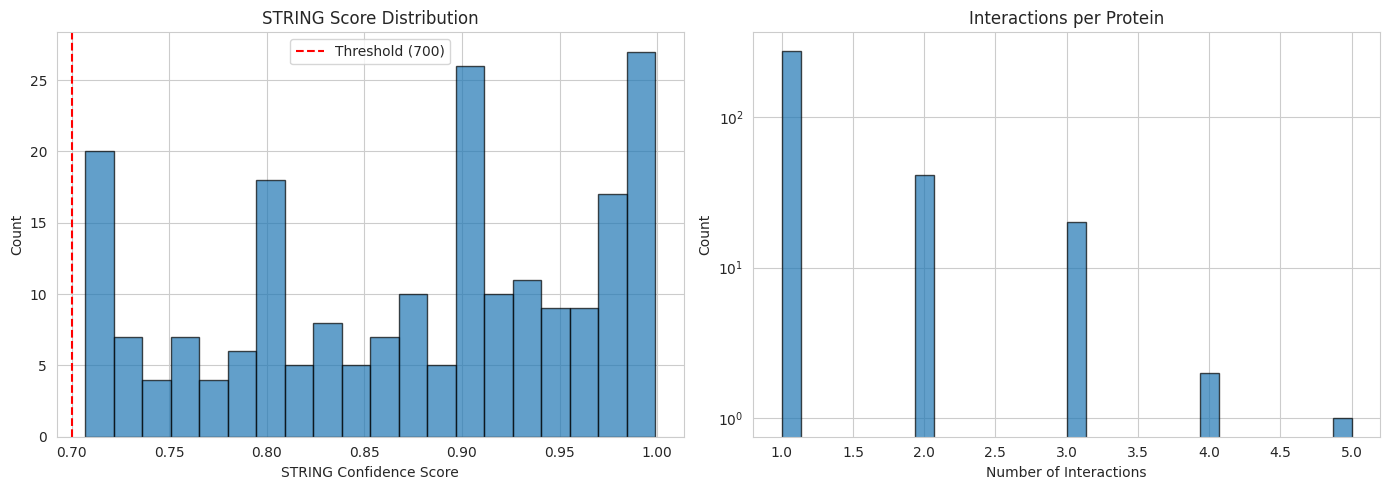

In [14]:
# Visualize interaction network properties
if len(interactions_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Score distribution
    axes[0].hist(interactions_df['score'], bins=20, edgecolor='black', alpha=0.7)
    axes[0].axvline(SCORE_THRESHOLD/1000, color='red', linestyle='--', label=f'Threshold ({SCORE_THRESHOLD})')
    axes[0].set_xlabel('STRING Confidence Score')
    axes[0].set_ylabel('Count')
    axes[0].set_title('STRING Score Distribution')
    axes[0].legend()
    
    # Interactions per protein (if protein columns exist)
    if 'preferredName_A' in interactions_df.columns and 'preferredName_B' in interactions_df.columns:
        protein_counts = pd.concat([
            interactions_df['preferredName_A'].value_counts(),
            interactions_df['preferredName_B'].value_counts()
        ]).groupby(level=0).sum().sort_values(ascending=False)
        
        axes[1].hist(protein_counts.values, bins=30, edgecolor='black', alpha=0.7)
        axes[1].set_xlabel('Number of Interactions')
        axes[1].set_ylabel('Count')
        axes[1].set_title('Interactions per Protein')
        axes[1].set_yscale('log')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  No interactions to visualize")

## 3. Match Interactions to pLLPS Dataset

In [16]:
# Match interactions to full dataset
if len(interactions_df) > 0:
    print("\n🔗 Matching interactions to pLLPS dataset...")
    
    # Reload the module to get updated function
    import importlib
    importlib.reload(lf)
    
    matched_df = lf.match_interactions_to_pllps(interactions_df, df_full)
    
    print(f"\n✅ Matching complete:")
    print(f"   Total interactions: {len(matched_df)}")
    if len(matched_df) > 0 and 'both_in_dataset' in matched_df.columns:
        print(f"   Both partners in dataset: {matched_df['both_in_dataset'].sum()}")
    if len(matched_df) > 0 and 'pllps_1' in matched_df.columns and 'pllps_2' in matched_df.columns:
        print(f"   Interactions with pLLPS scores: {matched_df[['pllps_1', 'pllps_2']].notna().all(axis=1).sum()}")
    
    # Save matched interactions
    if len(matched_df) > 0:
        lf.save_analysis_result(matched_df, 'string_interactions_matched', format='csv')
else:
    matched_df = pd.DataFrame()
    print("\n⚠️  No interactions to match")


🔗 Matching interactions to pLLPS dataset...

✅ Matching complete:
   Total interactions: 84
   Both partners in dataset: 84
   Interactions with pLLPS scores: 84
✅ Saved CSV to: results/string_interactions_matched.csv


In [9]:
# Show matched data
if len(matched_df) > 0:
    print("\n📋 Sample matched interactions:")
    display(matched_df[['protein1', 'protein2', 'score', 'pllps_1', 'pllps_2', 'both_in_dataset']].head(10))
    
    # Save matched interactions
    lf.save_analysis_result(matched_df, 'string_interactions_matched', format='csv')

In [10]:
# Visualize pLLPS scores of interacting proteins
if len(matched_df) > 0:
    complete_pairs = matched_df[matched_df['both_in_dataset']].copy()
    
    if len(complete_pairs) > 0:
        fig, ax = plt.subplots(figsize=(10, 8))
        
        scatter = ax.scatter(
            complete_pairs['pllps_1'], 
            complete_pairs['pllps_2'],
            c=complete_pairs['score'],
            cmap='viridis',
            alpha=0.6,
            s=50
        )
        
        # Add threshold lines
        ax.axhline(0.7, color='red', linestyle='--', alpha=0.5, label='High pLLPS threshold')
        ax.axvline(0.7, color='red', linestyle='--', alpha=0.5)
        
        ax.set_xlabel('pLLPS Score (Protein 1)')
        ax.set_ylabel('pLLPS Score (Protein 2)')
        ax.set_title('pLLPS Scores of Interacting Protein Pairs')
        ax.legend()
        
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('STRING Confidence Score')
        
        plt.tight_layout()
        plt.savefig('results/pllps_interaction_scatter.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✅ Saved plot: results/pllps_interaction_scatter.png")

## 4. Save Summary Statistics

In [11]:
# Create summary
if len(matched_df) > 0:
    complete_pairs = matched_df[matched_df['both_in_dataset']]
    
    summary = {
        'proteins_queried': len(protein_ids),
        'total_interactions': len(interactions_df),
        'matched_interactions': len(matched_df),
        'complete_pairs': len(complete_pairs),
        'score_threshold': SCORE_THRESHOLD,
        'unique_proteins_with_interactions': len(set(interactions_df['protein1'].tolist() + interactions_df['protein2'].tolist())),
        'errors_count': len(errors),
    }
    
    lf.save_analysis_result(summary, 'interaction_summary', format='json')
    
    print("\n" + "="*60)
    print("✅ All results saved successfully!")
    print("="*60)
    print(f"\n📊 Summary:")
    for key, value in summary.items():
        print(f"   {key}: {value}")
else:
    print("\n⚠️  No interactions to summarize")


⚠️  No interactions to summarize


In [12]:
# List all saved files
lf.list_saved_results()

📁 Found 14 result files in results:
   - classification_summary.json (0.4 KB)
   - communities_analysis.csv (2.7 KB)
   - full_dataset.csv (18.7 MB)
   - functional_group_interactions.csv (0.4 KB)
   - functional_group_pllps_analysis.csv (0.3 KB)
   - high_pllps_clusters.csv (2.6 KB)
   - high_pllps_hubs.csv (16.0 KB)
   - high_pllps_proteins.csv (6.1 MB)
   - high_pllps_proteins_connectivity.csv (23.6 KB)
   - hub_analysis_full.csv (311.4 KB)
   - llps_driven_clusters.csv (0.2 KB)
   - membrane_proteins.csv (6.9 MB)
   - membrane_proteins_full.csv (9.9 MB)
   - string_interactions_raw.csv (18.5 KB)


['classification_summary.json',
 'communities_analysis.csv',
 'full_dataset.csv',
 'functional_group_interactions.csv',
 'functional_group_pllps_analysis.csv',
 'high_pllps_clusters.csv',
 'high_pllps_hubs.csv',
 'high_pllps_proteins.csv',
 'high_pllps_proteins_connectivity.csv',
 'hub_analysis_full.csv',
 'llps_driven_clusters.csv',
 'membrane_proteins.csv',
 'membrane_proteins_full.csv',
 'string_interactions_raw.csv']

## Summary

✅ **Completed:**
1. Loaded high pLLPS proteins from previous analysis
2. Fetched protein-protein interactions from STRING database
3. Matched interactions to pLLPS dataset
4. Generated visualizations
5. Saved all results to `results/` directory

**Next step:** Run `03_enrichment_analysis.ipynb` to test for high-high pLLPS interaction enrichment.